In [1]:
import torch
import os
import random
import utils
import data_utils
import json

import cbm
import plots

/home/jovyan/Label-free-CBM/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [2]:
# change this to the correct model dir, everything else should be taken care of
load_dir = "saved_models/cub_lf_cbm"
device = "cuda"

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)
dataset = args["dataset"]
_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
model = cbm.load_cbm(load_dir, device)

In [3]:
val_d_probe = dataset+"_val"
cls_file = data_utils.LABEL_FILES[dataset]

val_data_t = data_utils.get_data(val_d_probe, preprocess=target_preprocess)
val_pil_data = data_utils.get_data(val_d_probe)

In [4]:
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

## Measure accuracy

In [5]:
accuracy = utils.get_accuracy_cbm(model, val_data_t, device)
print("Accuracy: {:.2f}%".format(accuracy*100))

100%|██████████| 24/24 [00:18<00:00,  1.27it/s]

Accuracy: 74.58%


## Show final layer weights for some classes

You can build a Sankey diagram of weights by copying the incoming weights printed below into https://sankeymatic.com/build/

In [6]:
to_show = random.choices([i for i in range(len(classes))], k=1)

for i in to_show:
    print("Output class:{} - {}".format(i, classes[i]))
    print("Incoming weights:")
    for j in range(len(concepts)):
        if torch.abs(model.final.weight[i,j])>0.05:
            print("{} [{:.4f}] {}".format(concepts[j], model.final.weight[i,j], classes[i]))

Output class:173 - Palm Warbler
Incoming weights:
Glossy black wings [0.5472] Palm Warbler
a black and white color scheme [-0.3324] Palm Warbler
a blue head [-0.4250] Palm Warbler
a duck-like bird [0.2490] Palm Warbler
a large, stocky bird [-0.1211] Palm Warbler
a medium-sized duck [0.2311] Palm Warbler
a red throat [0.2804] Palm Warbler
a small, thrush-like bird [0.1233] Palm Warbler
a stout, conical bill [-0.2661] Palm Warbler
a white head and neck [0.2432] Palm Warbler
a yellow body [0.1369] Palm Warbler
beak and legs are black [0.1274] Palm Warbler
black and white plumage [-0.4368] Palm Warbler
black head, neck, and back [-0.1855] Palm Warbler
blue wings [-0.2863] Palm Warbler
bright golden-yellow plumage [0.1494] Palm Warbler
large webbed feet [0.1513] Palm Warbler
olive-colored sides [0.2845] Palm Warbler
olive-green back [0.3765] Palm Warbler
pale pink legs [0.3732] Palm Warbler
red and yellow wingtips [1.0049] Palm Warbler
streaks of white on its wings [0.1687] Palm Warbler
whi

In [7]:
to_show = random.choices([i for i in range(len(classes))], k=2)

top_weights, top_weight_ids = torch.topk(model.final.weight, k=5, dim=1)
bottom_weights, bottom_weight_ids = torch.topk(model.final.weight, k=5, dim=1, largest=False)

for i in to_show:
    print("Class {} - {}".format(i, classes[i]))
    out = "Highest weights: "
    for j in range(top_weights.shape[1]):
        idx = int(top_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], top_weights[i, j])
    print(out)
    out = "Lowest weights: "
    for j in range(bottom_weights.shape[1]):
        idx = int(bottom_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], bottom_weights[i, j])
    print(out + "\n")

Class 19 - Yellow breasted Chat
Highest weights: orange throat:1.069, a bright orange breast:0.660, a blue-gray body:0.533, a yellow throat and breast:0.464, a large, orange bill:0.425, 
Lowest weights: red feathers:-0.523, long, black ear tufts:-0.494, a long, orange-red beak:-0.311, pale pink legs:-0.259, a dark brown or black color:-0.211, 

Class 66 - Anna Hummingbird
Highest weights: a pink bill:1.145, a purple-red head and breast:0.851, green wings:0.666, greenish upperparts:0.414, a swift, acrobatic flight:0.362, 
Lowest weights: a small, brown body:-0.270, a yellowish breast:-0.200, a white belly:-0.166, a small, sparrow-like body:-0.142, gray feathers:-0.141, 



In [8]:
# Some features may not have any non-zero outgoing weights, 
# i.e. these are not used by the model and should be deleted for better performance
weight_contribs = torch.sum(torch.abs(model.final.weight), dim=0)
print("Num concepts with outgoing weights:{}/{}".format(torch.sum(weight_contribs>1e-5), len(weight_contribs)))

Num concepts with outgoing weights:208/208


## Explain model reasoning for random inputs

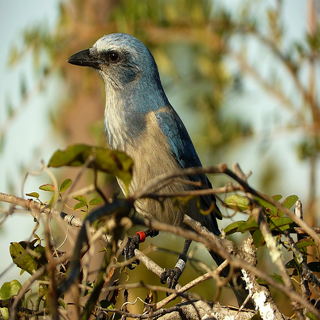

Image:2083 Gt:Florida Jay, 1st Pred:Florida Jay, 10.260, 2nd Pred:Lazuli Bunting, 5.549


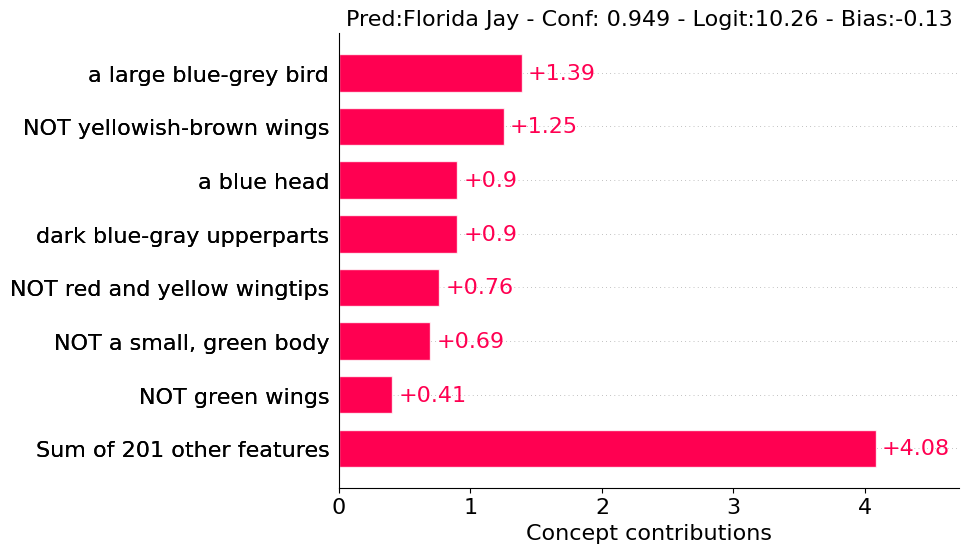

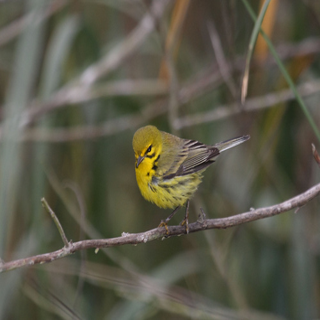

Image:5057 Gt:Prairie Warbler, 1st Pred:Prairie Warbler, 9.921, 2nd Pred:Cape May Warbler, 4.896


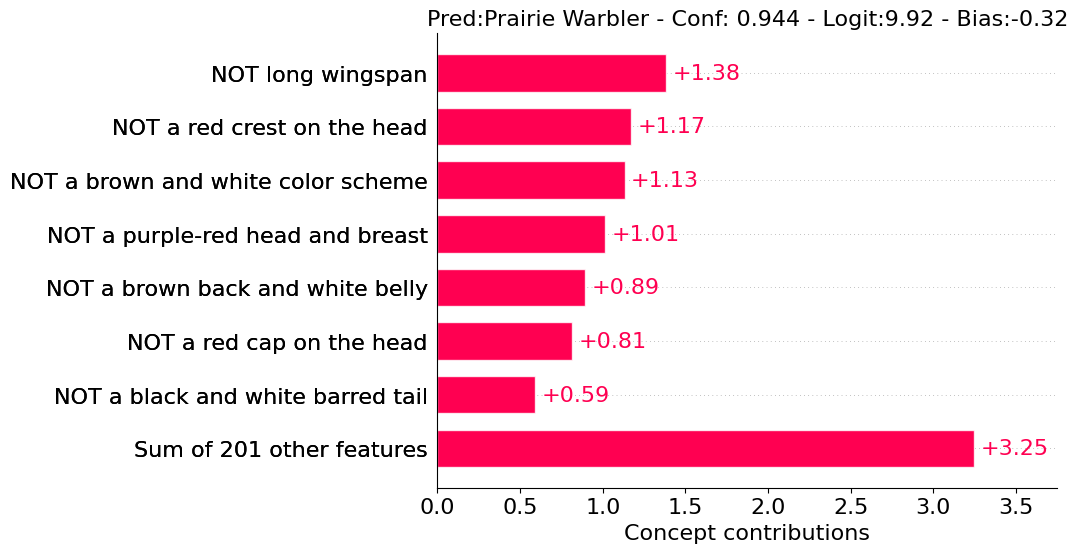

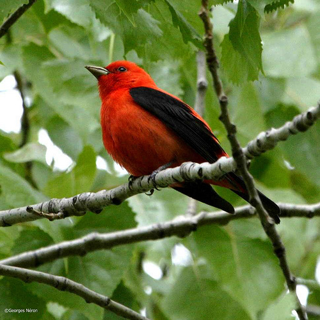

Image:3977 Gt:Scarlet Tanager, 1st Pred:Scarlet Tanager, 12.028, 2nd Pred:Vermilion Flycatcher, 7.300


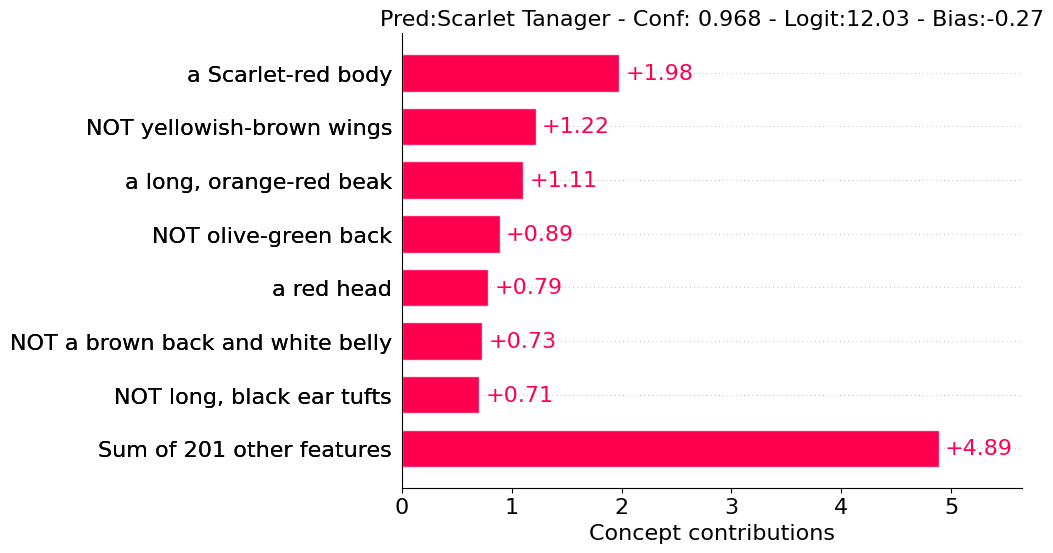

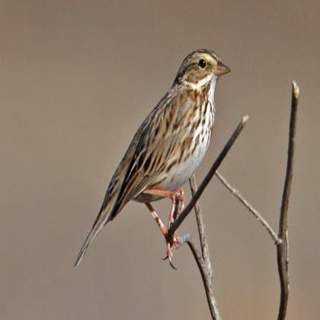

Image:3623 Gt:Savannah Sparrow, 1st Pred:Savannah Sparrow, 9.331, 2nd Pred:Le Conte Sparrow, 4.982


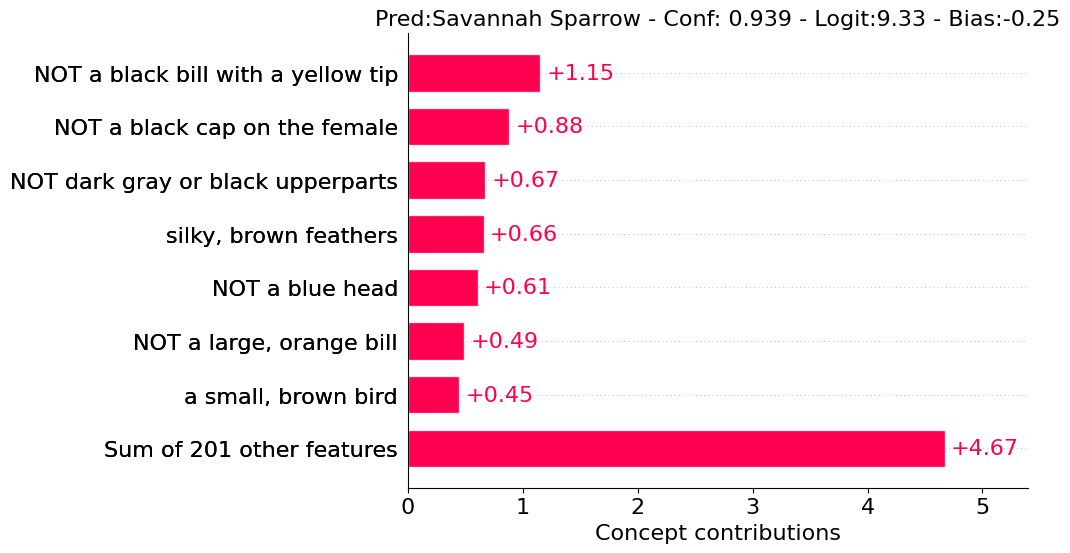

In [9]:
to_display = random.sample([i for i in range(len(val_pil_data))], k=4)

with torch.no_grad():
    for i in to_display:
        image, label = val_pil_data[i]
        x, _ = val_data_t[i]
        x = x.unsqueeze(0).to(device)
        display(image.resize([320,320]))
        
        outputs, concept_act = model(x)
        
        top_logit_vals, top_classes = torch.topk(outputs[0], dim=0, k=2)
        conf = torch.nn.functional.softmax(outputs[0], dim=0)
        print("Image:{} Gt:{}, 1st Pred:{}, {:.3f}, 2nd Pred:{}, {:.3f}".format(i, classes[int(label)], classes[top_classes[0]], top_logit_vals[0],
                                                                      classes[top_classes[1]], top_logit_vals[1]))
        
        for k in range(1):
            contributions = concept_act[0]*model.final.weight[top_classes[k], :]
            feature_names = [("NOT " if concept_act[0][i] < 0 else "") + concepts[i] for i in range(len(concepts))]
            values = contributions.cpu().numpy()
            max_display = min(int(sum(abs(values)>0.005))+1, 8)
            title = "Pred:{} - Conf: {:.3f} - Logit:{:.2f} - Bias:{:.2f}".format(classes[top_classes[k]],
                             conf[top_classes[k]], top_logit_vals[k], model.final.bias[top_classes[k]])
            plots.bar(values, feature_names, max_display=max_display, title=title, fontsize=16)